In [1]:
pip install scikit-surprise

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

from surprise import Dataset, Reader
from surprise import KNNBasic, KNNWithMeans, KNNWithZScore, KNNBaseline
from surprise.model_selection import cross_validate, train_test_split, GridSearchCV

In [3]:
# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

**Load Preprocessed Data**

Define Surprise reader and print first 5 data of ratings.

In [5]:
# Load datasets from local directory
movies_df = pd.read_csv("./CleanedData/movies_cleaned.csv") 
ratings_df = pd.read_csv("./CleanedData/ratings_cleaned.csv")

reader = Reader(rating_scale=(1,10))
data = Dataset.load_from_df(ratings_df[['userId', 'movieId', 'rating']], reader)

print(ratings_df.head())

   userId  movieId  rating
0     671     6565     3.5
1     671     6385     2.5
2     671     6365     4.0
3     671     6269     4.0
4     671     6268     2.5


In [6]:
print('Number of ratings: %d\nNumber of movie: %d\nNumber of users: %d' % (len(ratings_df), len(ratings_df['movieId'].unique()), len(ratings_df['userId'].unique())))

Number of ratings: 100004
Number of movie: 9066
Number of users: 671


#### KNN Model Selection
K-Nearest Neighbours algorithm calculates the distances between users or items and finds the closest ones = the most similar ones.

In [8]:
### Model-related functions
def get_model_name(model):
    return str(model).split('.')[-1].split(' ')[0].replace("'>", "")

In [9]:
def generate_models_dict(models, sim_names, user_based):
    models_dict = {}

    for sim_name in sim_names:
        sim_dict = {
            'name': sim_name,
            'user_based': user_based
        }
        for model in models:
            model_name = get_model_name(model) + ' ' + sim_name
            models_dict[model_name] = model(sim_options=sim_dict)

    return models_dict

In [10]:
def cv_multiple_models(data, models_dict, cv=3):
    # Set seed for reproducibility
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    
    results_list = []

    for model_name, model in models_dict.items():
        print('\n---> CV for %s...' % model_name)

        cv_results = cross_validate(model, data, cv=cv, verbose=False)
        tmp = pd.DataFrame(cv_results).mean(numeric_only=True)
        tmp['model'] = model_name
        results_list.append(tmp)

    results = pd.concat(results_list, axis=1).T.reset_index(drop=True)
    return results


In [11]:
models1 = generate_models_dict([KNNBasic, KNNWithMeans, KNNWithZScore, KNNBaseline], ['msd'], True)
results1 = cv_multiple_models(data, models1)
models1 = None
display(results1)


---> CV for KNNBasic msd...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.

---> CV for KNNWithMeans msd...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.

---> CV for KNNWithZScore msd...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.

---> CV for KNNBaseline msd...
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimat

,test_rmse,test_mae,fit_time,test_time,model
0,0.980318,0.753975,0.134808,1.511246,KNNBasic msd
1,0.929405,0.711189,0.11452,1.454459,KNNWithMeans msd
2,0.927855,0.705946,0.161149,1.727959,KNNWithZScore msd
3,0.905572,0.694072,0.210545,1.667219,KNNBaseline msd


In [12]:
def draw_model_results(results):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    plt.xticks(rotation=90)

    palette = sns.color_palette("RdBu", len(results))

    sns.barplot(x='model', y='test_rmse', data=results, palette=palette, ax=ax1)
    ax1.set_title('Test RMSE and fit time of evaluated models')

    ax2 = ax1.twinx()
    sns.scatterplot(x='model', y='fit_time', data=results, color='black', ax=ax2)
    ax2.set(ylim=(0, results['fit_time'].max() * 1.1))

    plt.show()

C:\Users\wongj\AppData\Local\Temp\ipykernel_22340\4214428858.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='test_rmse', data=results, palette=palette, ax=ax1)


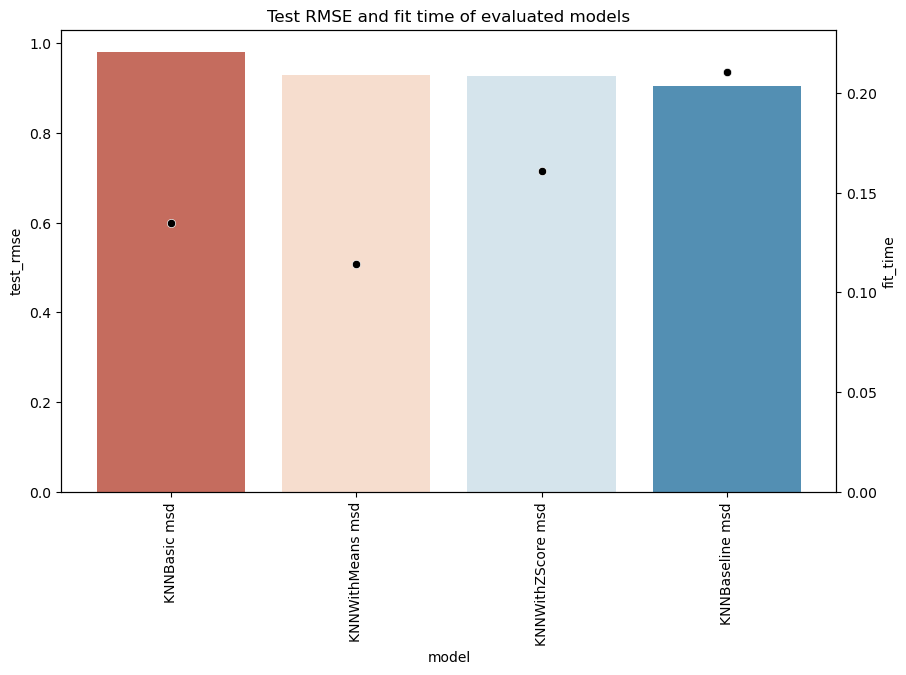

In [13]:
draw_model_results(results1)

#### User-Item Model Selection
User-Item approach is to determine a set of the most similar users to the user U (based on their past ratings) and to calculate the rating for the item I based on the ratings assigned by those users.

In [15]:
models2 = generate_models_dict([KNNBaseline], ['cosine', 'msd', 'pearson'], True)
results2 = cv_multiple_models(data, models2)
models2 = None
display(results2)


---> CV for KNNBaseline cosine...
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.

---> CV for KNNBaseline msd...
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.

---> CV for KNNBaseline pearson...
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pea

,test_rmse,test_mae,fit_time,test_time,model
0,0.909265,0.697754,0.300701,1.674407,KNNBaseline cosine
1,0.905806,0.693232,0.257311,1.676794,KNNBaseline msd
2,0.918114,0.702395,0.820007,6.855152,KNNBaseline pearson


#### Item-Item Model Selection
Item-Item approach is to determine a set of the most similar items to the item I (based on the past ratings of other users) and to calculate the rating for the item I based on the ratings of similar items rated by the user U.

In [17]:
models3 = generate_models_dict([KNNBaseline], ['cosine', 'msd', 'pearson'], False)
results3 = cv_multiple_models(data, models3)
models3 = None
display(results3)


---> CV for KNNBaseline cosine...
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.

---> CV for KNNBaseline msd...
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.

---> CV for KNNBaseline pearson...
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pea

,test_rmse,test_mae,fit_time,test_time,model
0,0.911372,0.703843,7.660954,5.937711,KNNBaseline cosine
1,0.891889,0.684734,4.834469,11.285256,KNNBaseline msd
2,0.906201,0.695894,7.022947,6.662628,KNNBaseline pearson


C:\Users\wongj\AppData\Local\Temp\ipykernel_22340\4214428858.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model', y='test_rmse', data=results, palette=palette, ax=ax1)


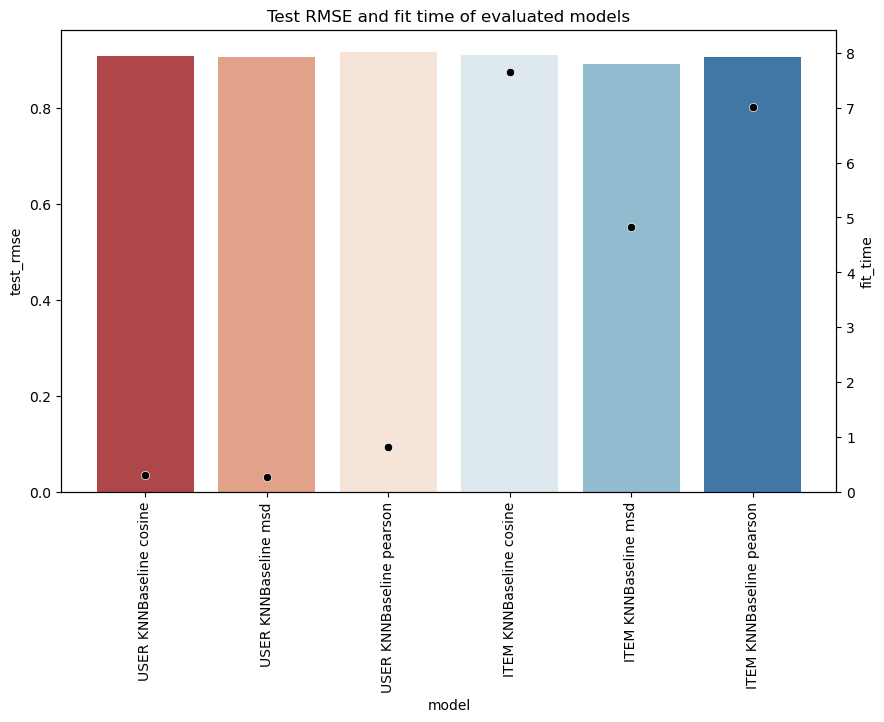

In [18]:
results2['model'] = 'USER ' + results2['model']
results3['model'] = 'ITEM ' + results3['model']

draw_model_results(pd.concat([results2, results3]))

#### Memory Based Model Optimisation with GridSearch CV
Grid Search Cross Validation computes accuracy metrics for an algorithm on various combinations of parameters, over a cross-validation procedure. It's useful for finding the best configuration of parameters
The best set of parameters (in terms of RMSE) obtained by GridSearch:

KNNBaseline, item-item, Pearson similarity metric
k = 50
min_k = 5
min_support = 1.

In [20]:
param_grid = {'k': [40,45,50],
              'min_k': [1,3,5],
              'sim_options': {'name': ['pearson'],
                              'min_support': [1, 5],
                              'user_based': [False]}
              }
gs = GridSearchCV(KNNBaseline, param_grid, measures=['rmse', 'mae'], cv=3, joblib_verbose=1)

gs.fit(data)
print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als.

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  6.4min


Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
0.8916353689286282
{'k': 50, 'min_k': 5, 'sim_options': {'name': 'pearson', 'min_support': 5, 'user_based': False}}


#### Analysis of Collaborative Filtering model results

In [22]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=RANDOM_SEED)

sim_options = {
    'name': 'pearson',
    'user_based': False,
    'min_support': 1
}

model = KNNWithMeans(k=50, min_k=5, sim_options=sim_options)
model.fit(trainset)
predictions = model.test(testset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


In [23]:
def k_from_details(details):
    try:
        return details['actual_k']
    except KeyError:
        return 1000

In [24]:
df_pred = pd.DataFrame(predictions, columns=['userId', 'movieId', 'actual_rating', 'pred_rating', 'details'])

df_pred['k'] = df_pred['details'].apply(k_from_details)
df_pred['impossible'] = df_pred['details'].apply(lambda x: x['was_impossible'])
df_pred['pred_rating_round'] = df_pred['pred_rating'].round()
df_pred['abs_err'] = abs(df_pred['pred_rating'] - df_pred['actual_rating'])
df_pred.drop(['details'], axis=1, inplace=True)

df_pred.sample(5)

,userId,movieId,actual_rating,pred_rating,k,impossible,pred_rating_round,abs_err
924,419,21,3.5,3.512279,29,False,4.0,0.012279
15680,547,2590,4.0,3.611694,50,False,4.0,0.388306
13960,92,34,5.0,3.270806,50,False,3.0,1.729194
13375,641,1020,4.0,3.818191,50,False,4.0,0.181809
12319,73,3052,3.0,3.555505,50,False,4.0,0.555505


#### Distribution of actual and predicted ratings in the test set

C:\Users\wongj\AppData\Local\Temp\ipykernel_22340\2951038081.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='actual_rating', data=df_pred, palette=palette, ax=ax1)
C:\Users\wongj\AppData\Local\Temp\ipykernel_22340\2951038081.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pred_rating_round', data=df_pred, palette=palette, ax=ax2)
C:\Users\wongj\AppData\Local\Temp\ipykernel_22340\2951038081.py:7: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.countplot(x='pred_rating_round', data=df_pred, palette=palette, ax=ax2)


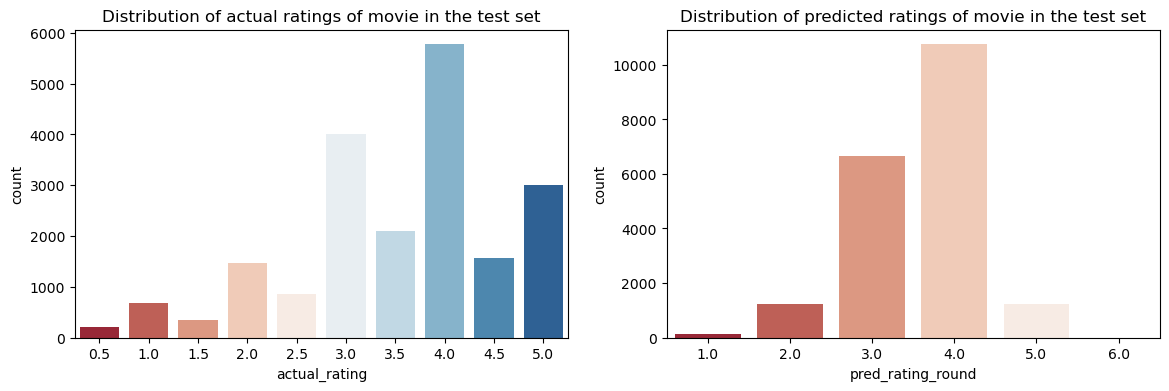

In [26]:
palette = sns.color_palette("RdBu", 10)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

sns.countplot(x='actual_rating', data=df_pred, palette=palette, ax=ax1)
ax1.set_title('Distribution of actual ratings of movie in the test set')

sns.countplot(x='pred_rating_round', data=df_pred, palette=palette, ax=ax2)
ax2.set_title('Distribution of predicted ratings of movie in the test set')

plt.show()

###
Absolute error of predicted ratings

C:\Users\wongj\AppData\Local\Temp\ipykernel_22340\3785201354.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_pred['abs_err'], color='#2f6194', ax=ax1)
C:\Users\wongj\AppData\Local\Temp\ipykernel_22340\3785201354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='actual_rating', y='abs_err', data=df_pred_err, palette=palette, ax=ax2)


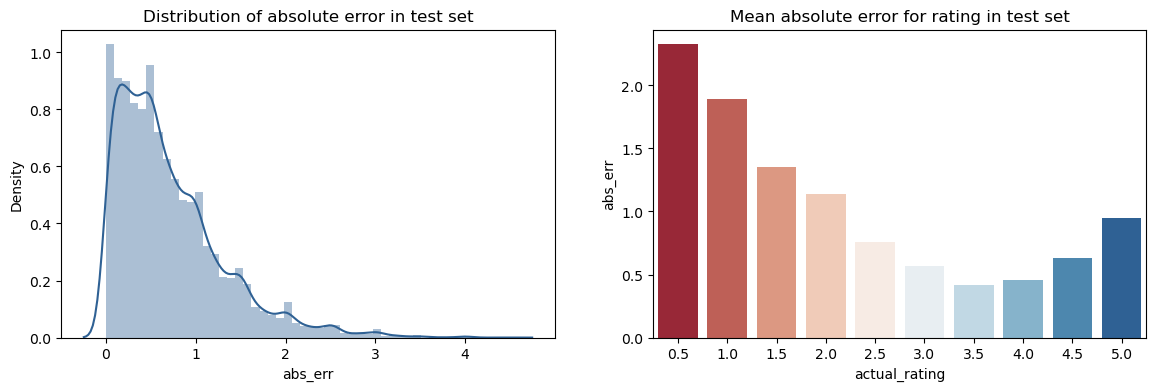

In [28]:
df_pred_err = df_pred.groupby('actual_rating')['abs_err'].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

sns.distplot(df_pred['abs_err'], color='#2f6194', ax=ax1)
ax1.set_title('Distribution of absolute error in test set')

sns.barplot(x='actual_rating', y='abs_err', data=df_pred_err, palette=palette, ax=ax2)
ax2.set_title('Mean absolute error for rating in test set')

plt.show()

#### Analysis of predicted ratings of a particular user

In [30]:
def short_title(title, max_len=40):
    title = str(title).split(' ')
    short_title = ''

    for i in range(len(title)):
        if len(short_title) < max_len:
            short_title = ' '.join([short_title, title[i]])
    short_title = short_title.strip()
    return short_title

In [31]:
movies_df = pd.read_csv("./CleanedData/movies_cleaned.csv") 

df_pred_ext = df_pred.merge(movies_df[['movieId', 'title']], on='movieId', how='left')
df_pred_ext['title_short'] = df_pred_ext['movieId'].apply(short_title)

C:\Users\wongj\AppData\Local\Temp\ipykernel_22340\1095176831.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='actual_rating', data=df_pred_user, palette=sns.color_palette("RdBu", len(df_pred_user['actual_rating'].unique())), ax=ax1)
C:\Users\wongj\AppData\Local\Temp\ipykernel_22340\1095176831.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pred_rating_round', data=df_pred_user, palette=sns.color_palette("RdBu", len(df_pred_user['pred_rating_round'].unique())), ax=ax2)


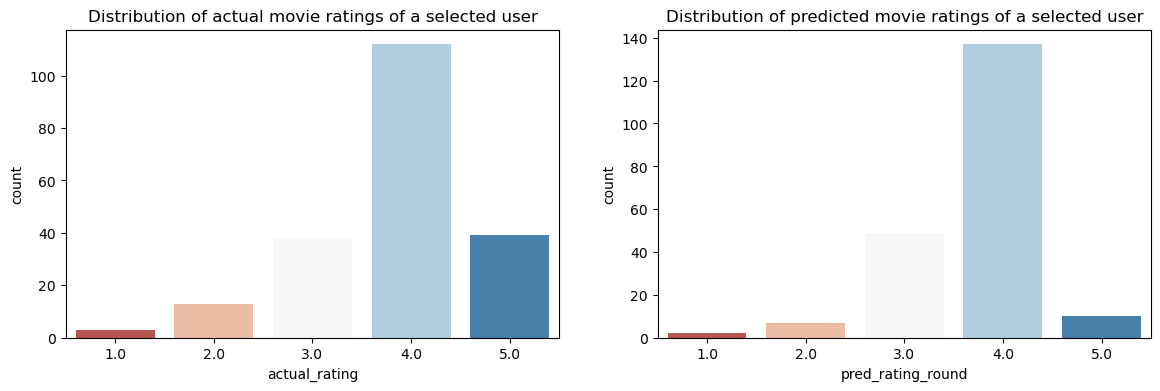

In [32]:
selected_user_id = 30

df_pred_user = df_pred_ext[df_pred_ext['userId']==selected_user_id]

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

sns.countplot(x='actual_rating', data=df_pred_user, palette=sns.color_palette("RdBu", len(df_pred_user['actual_rating'].unique())), ax=ax1)
ax1.set_title('Distribution of actual movie ratings of a selected user')

sns.countplot(x='pred_rating_round', data=df_pred_user, palette=sns.color_palette("RdBu", len(df_pred_user['pred_rating_round'].unique())), ax=ax2)
ax2.set_title('Distribution of predicted movie ratings of a selected user')

plt.show()

C:\Users\wongj\AppData\Local\Temp\ipykernel_22340\1188659591.py:6: UserWarning: The palette list has more values (12) than needed (2), which may not be intended.
  sns.barplot(x='title_short', y='rating', hue='prediction', data=df_pred_sample, palette=sns.color_palette("Paired"))


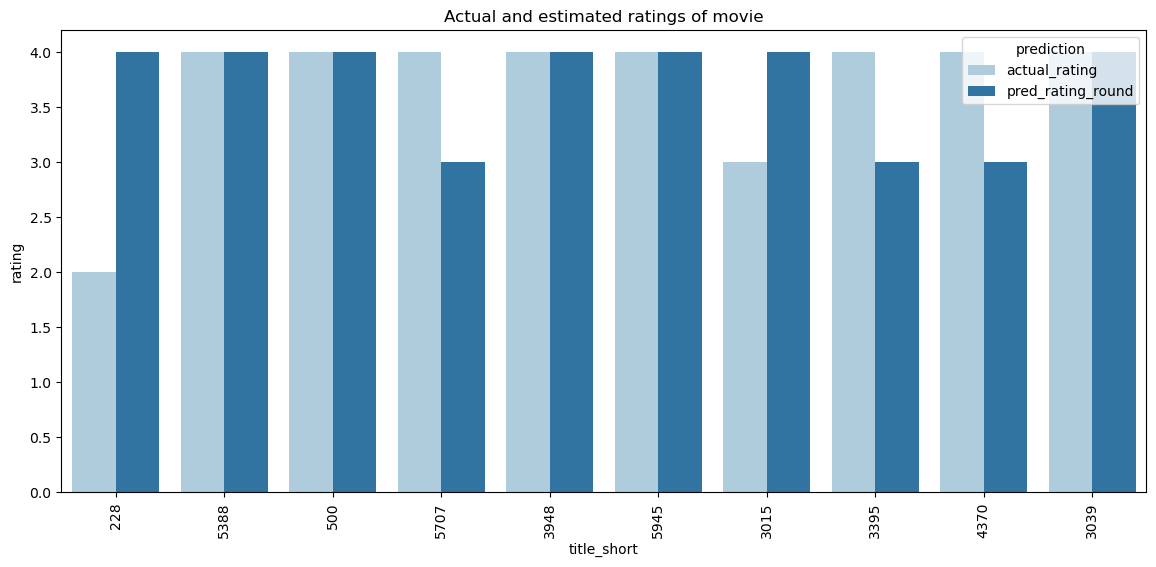

In [33]:
df_pred_sample = df_pred_user[df_pred_user['pred_rating_round'].notna()].sample(10)
df_pred_sample = pd.melt(df_pred_sample[['title_short', 'actual_rating', 'pred_rating_round']], id_vars='title_short', var_name='prediction', value_name='rating')

fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(x='title_short', y='rating', hue='prediction', data=df_pred_sample, palette=sns.color_palette("Paired"))
ax.set_title('Actual and estimated ratings of movie')
plt.xticks(rotation=90)

plt.show()

#### Testing Recommendation System

In [35]:
# Make sure both DataFrames have the same movieId type
ratings_df['movieId'] = ratings_df['movieId'].astype(int)
movies_df['movieId'] = movies_df['movieId'].astype(int)

# Keep only movies that exist in movies_df
ratings_df = ratings_df[ratings_df['movieId'].isin(movies_df['movieId'])]


In [36]:
# Find one user who gave a high rating
import random

sample = ratings_df[ratings_df['rating'] >= 4.5].sample(1, random_state=RANDOM_SEED)
user_id = sample['userId'].values[0]
movie_id = sample['movieId'].values[0]

movie_row = movies_df[movies_df['movieId'] == movie_id]
if not movie_row.empty:
    movie_title = movie_row['title'].values[0]
else:
    movie_title = "Unknown Title"

print(f"User {user_id} rated '{movie_title}' with 4.5 stars.")


User 654 rated 'Shiloh' with 4.5 stars.


In [37]:
# Movies user hasn't rated
user_rated = ratings_df[ratings_df['userId'] == user_id]['movieId'].values
all_movies = ratings_df['movieId'].unique()
unrated_movies = [movie for movie in all_movies if movie not in user_rated]
valid_unrated = [m for m in unrated_movies if m in movies_df['movieId'].values]

predictions = []
for movie in valid_unrated:
    pred = model.predict(user_id, movie)
    predictions.append((movie, pred.est))

# Sort and show top 5
top_5 = sorted(predictions, key=lambda x: x[1], reverse=True)[:5]

print(f"\nTop 5 recommended movies for user {user_id}:")
for movie_id, est_rating in top_5:
    title_row = movies_df[movies_df['movieId'] == movie_id]
    title = title_row['title'].values[0] if not title_row.empty else "Unknown Title"
    print(f"{title} — Predicted Rating: {est_rating:.2f}")



Top 5 recommended movies for user 654:
Army Of Darkness — Predicted Rating: 5.54
Blown Away — Predicted Rating: 5.45
Match Point — Predicted Rating: 5.38
Mary Shelleys Frankenstein — Predicted Rating: 5.32
Speed Racer — Predicted Rating: 5.31


#### Save Model 

In [40]:
import pickle
import os

# Save directory
local_dir = "./Pickle"
os.makedirs(local_dir, exist_ok=True)

# Save the best model found by GridSearchCV
best_model = gs.best_estimator['rmse']

# Save to file
with open(os.path.join(local_dir, 'collab_best_model_rmse.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

print("✅ Collaborative filtering model saved as 'collab_best_model_rmse.pkl'")


✅ Collaborative filtering model saved as 'collab_best_model_rmse.pkl'
